# Gaussian Process (Kriging) Tutorial

## Gaussian Process Background

A Gaussian process (GP) model is

$$ f \sim \mathcal{GP}(m, k),$$

where

- $m(\underline{x})$ is the *mean function*
- $k(\underline{x}, \underline{x}')$ is the *covariance function*. Another word for covariance function is **kernel**.

Here, $f(\underline{x})$ are observations at location $\underline{x}$. The location $\underline{x}$ we assume to be a $d$-dimensional vector, so $\underline{x} \in \mathbb{R}^d$. If $\underline{x}$ is $d$-dimensional, the Gaussian process is said to $d$-dimensional. A Gaussian process assumes that:

$$ f(\underline{x}) \sim \mathcal{N}(m(\underline{x}), k(\underline{x},\underline{x})). $$

In general, a GP assumes that the *joint distribution* of the observations at any locations $\underline{x}_1,\ldots, \underline{x}_n$ is multivariate normally distributed. Another word for the *multivariate normal distribution*, or indeed the *normal distribution*, is the **Gaussian distribution**. This is why Gaussian processes are called **Gaussian**.

$$ \begin{pmatrix} f(\underline{x}_1) \\ f(\underline{x}_2) \\ \vdots \\ f(\underline{x}_n) \end{pmatrix} \sim \mathcal{N}\left( \begin{pmatrix} m(\underline{x}_1) \\ m(\underline{x}_2) \\ \vdots \\ m(\underline{x}_n) \end{pmatrix}, \begin{pmatrix} k(\underline{x}_1, \underline{x}_1) & k(\underline{x}_1, \underline{x}_2) & \cdots & k(\underline{x}_1, \underline{x}_n) \\ k(\underline{x}_2, \underline{x}_1) & k(\underline{x}_2, \underline{x}_2) & \cdots & k(\underline{x}_2, \underline{x}_n) \\ \vdots & \vdots & \ddots & \vdots \\ k(\underline{x}_n, \underline{x}_1) & k(\underline{x}_n, \underline{x}_2) & \cdots & k(\underline{x}_n, \underline{x}_n)  \end{pmatrix}  \right). $$

The matrix above is the *covariance matrix*, which we can write as:

$$ K_{X,X} =  \begin{pmatrix} k(\underline{x}_1, \underline{x}_1) & k(\underline{x}_1, \underline{x}_2) & \cdots & k(\underline{x}_1, \underline{x}_n) \\ k(\underline{x}_2, \underline{x}_1) & k(\underline{x}_2, \underline{x}_2) & \cdots & k(\underline{x}_2, \underline{x}_n) \\ \vdots & \vdots & \ddots & \vdots \\ k(\underline{x}_n, \underline{x}_1) & k(\underline{x}_n, \underline{x}_2) & \cdots & k(\underline{x}_n, \underline{x}_n)  \end{pmatrix} .$$

The covariance matrix is defined by the $(i,j)\text{th}$ element being $[K_{X,X}]_{ij} = k(\underline{x}_i, \underline{x}_j)$.


### Covariance Function

The covariance function specifies the spatial covariance between pairs of location $\underline{x}$ and $\underline{x}'$. That is,

$$ k(\underline{x}, \underline{x}') = \text{Cov}[f(\underline{x}), f(\underline{x}')]. $$

An example of a covariance function is the *RBF* covariance function (sometimes called the *squared exponential kernel*):

$$ k(\underline{x}, \underline{x}') = \lambda \exp\left\{-\frac{\|\underline{x} - \underline{x}'\|^2}{2\ell}\right\}. $$

In general, a covariance function may depend on additional parameters. In the example above, $\lambda$ is known as the **amplitude parameter** and $\ell$  is known as the **lengthscale parameter** (sometimes also called the **bandwidth parameter**).

### Posterior GP

In Bayesian inference, the **posterior** refers to the distribution after **conditioning on data**. In the context of Gaussian processes:

Suppose we had some data, which we denote $\mathcal{D}$. The data looks like $(\underline{x_1},y_1), \ldots, (\underline{x_n}, y_n)$. Here, the $y_i$ are our *response variables*. In GP regression, we condition on our data to obtain a *posterior GP*. 

$$ f\mid \mathcal{D} \sim \mathcal{GP}(\tilde{m}, \tilde{k}). $$

The posterior GP is again a Gaussian process, but with a different mean function and covariance function. The posterior mean $\tilde{m}$ and posterior covariance function $\tilde{k}$ are:

$$
\begin{align*}
    \tilde{m}(\underline{x}) &= m(\underline{x}) + k(\underline{x},X)\big[K_{X,X} + \sigma^2 I_n\big]^{-1}\big(Y-m(X)\big), \\
    \tilde{k}(\underline{x}, \underline{x}') &= k(\underline{x},\underline{x}') - k(\underline{x},X)\big[K_{X,X} + \sigma^2 I_n\big]^{-1}k(X,\underline{x}'),
\end{align*}
$$

where

- $X = (\underline{x}_1,\ldots,\underline{x}_n)^\top$ is the $n\times d$ matrix of our $\underline{x}_i$ locations.
- $Y = (y_1,\ldots, y_n)^\top$ is the $n\times 1$ columnd vector of our $y_i$ response observations.
- $k(\underline{x}, X)$ is a $1\times n$ row-vector defined as $k(\underline{x},X) = (k(\underline{x}, \underline{x}_1), k(\underline{x}, \underline{x}_2),\ldots, k(\underline{x}, \underline{x}_n))$
- $\sigma^2$ is the variance in the error of our observations $y_i$
-  $I_n$ is the $n\times n$ identity matrix.



## Loading in Packages

In order to run different packages in Python, we have to first install them. As a beginner, I recommend installing [Anaconda](https://www.anaconda.com/download). Anaconda is a *package manager* which allows you to control the packages installed. It also allows you to directly install Python and use Jupyter Notebook. Here is a [link](https://www.python-engineer.com/posts/anaconda-basics/) to a tutorial for Anaconda.

Once you have Anaconda installed and have opened the Anaconda navigator, you can install the required packages using:

`conda install conda-forge::gpy`

`conda install conda-forge::matplotlib`

Here:

- `GPy` is a Gaussian process package. When installing `Gpy`, it should also install `numpy` and `scipy`. [Numpy](https://numpy.org/) is the standard scientific computing package in Python. It allows you to do the standard computational things you would do in MATLAB.

- `matplotlib` is the standard plotting package used in Python. There are some other alternatives, but this is the standard choice.

In [ ]:
import GPy
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams["figure.figsize"] = (6,4) #sets plotting size


## Numpy and Plotting Basics

Given a background in MATLAB, `numpy` should be quite intuitive. The only issue is the syntax for defining an array.

In [10]:
x = np.array([1,2,3])
y = np.array([2,-3,4])

print(x * 2)
print(x + 3)
print(x * y)

[2 4 6]
[4 5 6]
[ 2 -6 12]


We can plot using `matplotlib`.

Text(0, 0.5, '$y$')

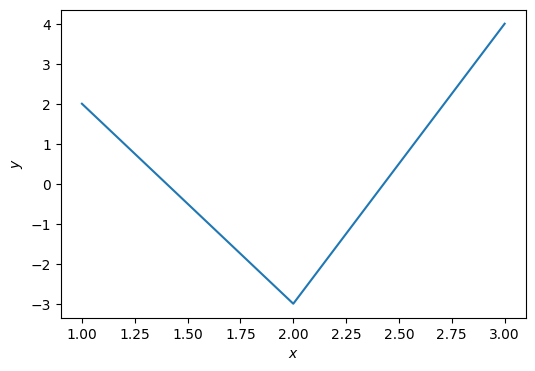

In [31]:
plt.plot(x,y)
plt.xlabel('$x$')
plt.ylabel('$y$')

## Gaussian Processes using `GPy`

The general process in `GPy` for defining a Gaussian process $\mathcal{GP}(m,k)$ is:

1. Define the choice of covariance function $k$
2. Define our data
3. Compute the posterior using the data

By default, `GPy` assumes the mean function $m(\underline{x}) = 0$ is the zero-function.

In the following we define a one-dimensional Gaussian process, so $\underline{x}_i = x_i$ is just a number, or a $1\times 1$ vector.

#### Define a covariance function

In the following we define the RBF covariance function, defined above.

In [14]:
covariance_function = GPy.kern.RBF(input_dim=1, variance=1., lengthscale=1.)

#### Define data

Locations X: [ 0.86001901  2.04426701  2.24113818  0.09677491  1.31629492 -2.69210514
 -2.38238972 -0.40531386 -2.19660777 -0.35708977 -2.99097037  1.4312244
  1.18164238 -0.53215053 -2.38871119  1.3240178  -1.44623927  0.1757281
  2.78820797 -2.40534262]
Response Y: [ 0.76800474  0.88360412  0.88520671  0.01508699  0.9950182  -0.39036768
 -0.65758921 -0.41435242 -0.82267436 -0.38124921 -0.24707051  0.96315068
  0.90320389 -0.48474999 -0.66086696  0.9310794  -1.08978078  0.19945706
  0.31403865 -0.66259993]


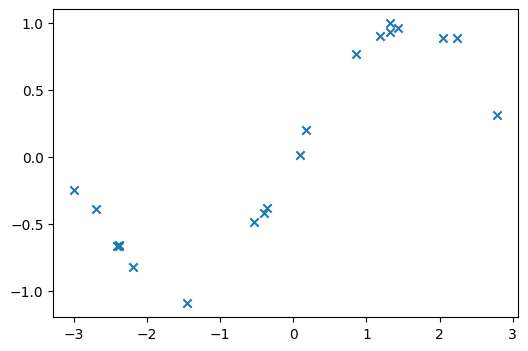

In [30]:
X = np.random.uniform(-3.,3.,(20,1))
Y = np.sin(X) + np.random.randn(20,1)*0.05

plt.scatter(X, Y, marker='x')
print('Locations X:', X.flatten())
print('Response Y:', Y.flatten())

#### Compute Posterior

In [19]:
gp = GPy.models.GPRegression(X,Y,covariance_function)


#### Plotting 

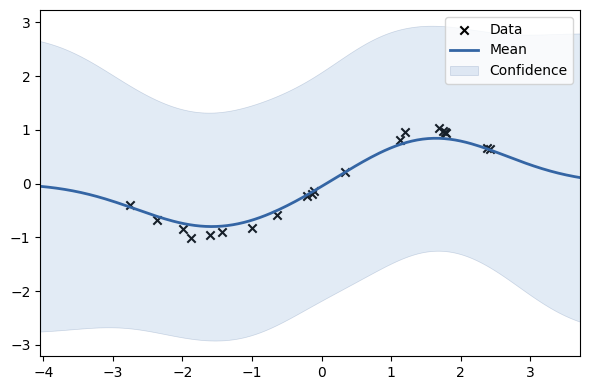

In [ ]:
fig = gp.plot()
plt.show()